# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## Notebook P3-22: HR RhythmFormer - SNR loss

### What this notebook does
Introduces RhythmFormer (Zou & Guo et al., 2024 - the same group as RhythmMamba) into the CRVSE pipeline and trains it with the 2026 SNR-loss recipe on one fixed subject-wise split. RhythmFormer is a pure-PyTorch periodic-sparse-attention transformer with a temporal-difference fusion stem; unlike RhythmMamba and PhysMamba it needs NO mamba-ssm CUDA kernels, only timm. It is the strongest published cross-dataset rPPG transformer (MMPD MAE 3.07, r 0.86) at ~3.3 M parameters and fewer MACs than PhysFormer.

### Why this experiment
The CRVSE weak spot is cross-dataset generalization (PhysDrive zero-shot, and the real-world domain gap of the live app). RhythmFormer was designed for exactly that - periodic sparse attention that models domain-invariant pulse structure. It is trained here with RhythmFormer's own recipe plus the SNR loss and read against the established CRVSE reference points - PhysNet v2 (shared 5.22, MCD 6.84; NB_P3_18) and the RhythmMamba v1 screen (shared 6.83, MCD 10.49; NB_P3_10).

### Recipe and rules
- Training follows RhythmFormer's own recipe (AdamW weight decay 0 + OneCycleLR, LR stepped once per batch), 30 epochs, batch 4, read from the official RhythmFormerTrainer. The OneCycle peak is set to 3e-3, with a non-finite-loss skip and a two-eval divergence guard for stable convergence. This differs from the cosine schedule of NB_P3_20/21 because it is the model's designed schedule.
- Loss = neg_pearson + LAMBDA_SNR * snr_loss (in-band SNR at the reference fundamental + first harmonic, per-sample fps, invalid-HR clips masked), each clip weighted by cardiac_sqi - the same CRVSE v2 loss used for PhysNet/PhysFormer/RhythmMamba.
- One fixed subject-wise split (seed 42). Training corpus = MCD + DLCN + UBFC-rPPG; PhysDrive is evaluation-only (zero-shot). Checkpoint on the shared MCD+DLCN+UBFC MAE.
- RhythmFormer is built with its author-default settings for 160-frame / 30 fps clips (topk 40); our 72x72 clips are upsampled to 128x128 (its designed input) inside rf_forward. No frames are rendered.

## 1. Imports & Config (+ clone RhythmFormer, install timm)

In [1]:
import os, sys, time, random, gc, glob, importlib
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

# Clone RhythmFormer (transformer - NO mamba-ssm dependency) and expose it on the path.
# Pinned to a specific commit so this notebook stays reproducible. The SHA was
# captured 2026-08-29 and may differ from the commit used in the original run,
# which was not recorded. The resolved SHA is printed into this cell's output.
REPO_URL = 'https://github.com/zizheng-guo/RhythmFormer'
REPO_SHA = '7c9cea2284cecc50e267abefce711a0eb6d72b6e'
if not os.path.exists('RhythmFormer'):
    os.system('git init -q RhythmFormer && git -C RhythmFormer remote add origin ' + REPO_URL)
    os.system('git -C RhythmFormer fetch -q --depth 1 origin ' + REPO_SHA)
    os.system('git -C RhythmFormer checkout -q FETCH_HEAD')
print('RhythmFormer commit:', os.popen('git -C RhythmFormer rev-parse HEAD').read().strip())
sys.path.append('RhythmFormer')
for d in glob.glob('RhythmFormer/**/', recursive=True):
    sys.path.append(d)
os.system('pip install timm einops -q')

# locate the four Phase-3 datasets across Kaggle inputs (PhysDrive is held-out eval)
WANT = ['mcd_phase3.h5', 'dlcn_phase3.h5', 'ubfc_rppg_phase3.h5', 'physdrive_phase3.h5']
H5_PATHS = []
for name in WANT:
    hits = list(Path('/kaggle/input').rglob(name))
    if hits:
        H5_PATHS.append(hits[0])
print('datasets found:', [p.name for p in H5_PATHS])

TRAIN_SET = {'MCD', 'DLCN', 'UBFC-rPPG'} # PhysDrive excluded from training (held-out)
SHARED_DATASETS = {'MCD', 'DLCN', 'UBFC-rPPG'} # checkpoint metric
# CRVSE reference points
REF_PHYSNET_V2 = {'MCD': 6.84, 'DLCN': 3.08, 'UBFC-rPPG': 3.13, 'shared': 5.22}   # NB_P3_18 best (the model to beat)
REF_RMAMBA_V1  = {'MCD': 10.49, 'DLCN': 2.32, 'UBFC-rPPG': 4.19, 'shared': 6.83}  # NB_P3_10 screen

CLIP_LEN = 160
IMG_SIZE = 72
BATCH_SIZE = 4 # RhythmFormer at 128x128 is heavier; drop to 2 if OOM
CLIPS_PER_REC = 2
NUM_WORKERS = 2
VAL_FRAC = 0.2
SEED = 42
AUG_PROB = 0.5
SPEED_MIN, SPEED_MAX = 0.7, 2.0
SQI_FLOOR = 0.05

# RhythmFormer recipe (official RhythmFormerTrainer: AdamW wd=0 + OneCycleLR max_lr, 30 epochs, batch 4).
# max_lr lowered from RhythmFormer's default 9e-3 to 3e-3: at 9e-3 the first run collapsed mid-schedule
# (shared MAE froze at ~42.9 from ep18 = constant-output divergence). Lower peak + the guards below stabilise it.
LR = 3e-3 # OneCycleLR max_lr (stabilised); RhythmFormer default is 9e-3
WEIGHT_DECAY = 0.0
GRAD_CLIP = 1.0
EPOCHS = 30
LAMBDA_SNR = 0.05
HR_LOW, HR_HIGH = 0.66, 3.0

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.backends.cudnn.benchmark = True
print('device:', device, '| train on:', sorted(TRAIN_SET), '| PhysDrive = held-out eval | max_lr', LR)

Cloning into 'RhythmFormer'...


datasets found: ['mcd_phase3.h5', 'dlcn_phase3.h5', 'ubfc_rppg_phase3.h5', 'physdrive_phase3.h5']
device: cuda | train on: ['DLCN', 'MCD', 'UBFC-rPPG'] | PhysDrive = held-out eval | max_lr 0.003


## 2. Data Loader - index, one fixed subject-split

In [2]:
def build_index(h5_paths, sqi_floor=SQI_FLOOR, clip_len=CLIP_LEN):
    index = []
    for path in h5_paths:
        with h5py.File(path, 'r') as f:
            for name in f.keys():
                a = f[name].attrs
                if not bool(a.get('usable', True)):
                    continue
                if float(a.get('cardiac_sqi', 0.0)) < sqi_floor:
                    continue
                n = int(a['n_frames'])
                if n < clip_len:
                    continue
                index.append(dict(file=str(path), group=name, dataset=str(a.get('dataset', Path(path).stem)),
                                  subject=str(a.get('subject_id', name)), n_frames=n,
                                  fps=float(a.get('fps', 30.0)), sqi=float(a.get('cardiac_sqi', 0.0))))
    return index


def subject_split(index, val_frac=VAL_FRAC, seed=SEED):
    subjects = sorted({r['dataset'] + '/' + r['subject'] for r in index})
    rng = random.Random(seed); rng.shuffle(subjects)
    n_val = max(1, int(round(len(subjects) * val_frac)))
    val_subj = set(subjects[:n_val])
    tr = [r for r in index if (r['dataset'] + '/' + r['subject']) not in val_subj]
    va = [r for r in index if (r['dataset'] + '/' + r['subject']) in val_subj]
    return tr, va, val_subj


def compute_hr(bvp, fps, low=HR_LOW, high=HR_HIGH):
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.size < 16 or not np.all(np.isfinite(x)) or np.std(x) < 1e-9:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(x.size))) ** 2
    fr = np.fft.rfftfreq(x.size, 1.0 / fps)
    b = (fr >= low) & (fr <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(fr[b][int(np.argmax(p[b]))] * 60.0)


class RPPGClipDataset(Dataset):
    def __init__(self, index, clip_len=CLIP_LEN, augment=False, clips_per_rec=1,
                 aug_prob=AUG_PROB, speed_range=(SPEED_MIN, SPEED_MAX), seed=SEED):
        self.index = index; self.clip_len = clip_len; self.augment = augment
        self.clips_per_rec = clips_per_rec; self.aug_prob = aug_prob; self.speed_range = speed_range
        self._files = {}; self._rng = np.random.default_rng(seed)

    def _h5(self, path):
        h = self._files.get(path)
        if h is None:
            h = h5py.File(path, 'r'); self._files[path] = h
        return h

    def __len__(self):
        return len(self.index) * self.clips_per_rec

    def __getitem__(self, i):
        rec = self.index[i % len(self.index)]; g = self._h5(rec['file'])[rec['group']]
        n, T = rec['n_frames'], self.clip_len
        if self.augment and self._rng.random() < self.aug_prob:
            src_len = int(round(T * float(self._rng.uniform(*self.speed_range))))
            src_len = max(T, min(src_len, n))
        else:
            src_len = T
        max_start = n - src_len
        start = int(self._rng.integers(0, max_start + 1)) if (self.augment and max_start > 0) else max_start // 2
        frames_src = g['frames'][start:start + src_len].astype(np.float32)
        bvp_src = g['bvp'][start:start + src_len].astype(np.float32)
        pos = np.linspace(0, src_len - 1, T)
        frames = frames_src[np.rint(pos).astype(int)]
        bvp = np.interp(pos, np.arange(src_len), bvp_src)
        hr_bpm = compute_hr(bvp, rec['fps'])
        if self.augment and self._rng.random() < 0.5:
            frames = frames[:, :, ::-1, :]
        m = frames.mean(axis=(0, 1, 2), keepdims=True); sd = frames.std(axis=(0, 1, 2), keepdims=True) + 1e-6
        frames = np.ascontiguousarray((frames - m) / sd)
        frames = torch.from_numpy(frames).permute(3, 0, 1, 2).float()
        bvp = (bvp - bvp.mean()) / (bvp.std() + 1e-6)
        bvp = torch.from_numpy(bvp.astype(np.float32))
        return dict(frames=frames, bvp=bvp,
                    hr=torch.tensor(hr_bpm if np.isfinite(hr_bpm) else 0.0, dtype=torch.float32),
                    sqi=torch.tensor(rec['sqi'], dtype=torch.float32),
                    fps=torch.tensor(rec['fps'], dtype=torch.float32),
                    dataset=rec['dataset'])


def worker_init_fn(worker_id):
    info = torch.utils.data.get_worker_info(); ds = info.dataset
    ds._files = {}; ds._rng = np.random.default_rng(SEED + 1000 * (worker_id + 1) + int(info.seed % 100000))


def make_loader(index, augment, clips_per_rec=1):
    ds = RPPGClipDataset(index, augment=augment, clips_per_rec=clips_per_rec)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=augment, num_workers=NUM_WORKERS,
                      worker_init_fn=worker_init_fn, pin_memory=True, drop_last=augment,
                      persistent_workers=(NUM_WORKERS > 0))


index = build_index(H5_PATHS)
train_all, val_idx, val_subj = subject_split(index)   # ONE fixed split
train_idx = [r for r in train_all if r['dataset'] in TRAIN_SET]
print('usable:', len(index), 'by dataset:', dict(Counter(r['dataset'] for r in index)))
print('val (FIXED):', len(val_idx), 'by dataset:', dict(Counter(r['dataset'] for r in val_idx)))
print('train recs:', len(train_idx), 'by dataset:', dict(Counter(r['dataset'] for r in train_idx)))

usable: 2276 by dataset: {'MCD': 1191, 'DLCN': 777, 'UBFC-rPPG': 42, 'PhysDrive': 266}
val (FIXED): 475 by dataset: {'MCD': 232, 'DLCN': 168, 'UBFC-rPPG': 7, 'PhysDrive': 68}
train recs: 1603 by dataset: {'MCD': 959, 'DLCN': 609, 'UBFC-rPPG': 35}


## 3. Model - RhythmFormer (official repo, no mamba-ssm)

In [3]:
# Import RhythmFormer (needs timm + its base/video_bra submodule; no mamba-ssm).
RhythmFormerClass = None
for modname in ['neural_methods.model.RhythmFormer', 'model.RhythmFormer', 'RhythmFormer']:
    try:
        m = importlib.import_module(modname)
        RhythmFormerClass = getattr(m, 'RhythmFormer')
        print('imported RhythmFormer from', modname)
        break
    except Exception as e:
        print('import', modname, 'failed:', repr(e))

if RhythmFormerClass is None:
    print('RhythmFormer class NOT found. Repo model .py files:')
    for pyf in glob.glob('RhythmFormer/**/*.py', recursive=True):
        try:
            if 'class RhythmFormer' in open(pyf, errors='ignore').read():
                print('   *class here*', pyf)
            else:
                print('   ', pyf)
        except Exception:
            print('   ', pyf)
    raise RuntimeError('Could not import RhythmFormer - paste this listing.')

RF_INPUT = 128   # RhythmFormer official spatial size (config RESIZE 128); our 72x72 clips are upsampled to this

def build_rhythmformer():
    # author defaults (frame=160, image_size=(160,128,128), topks=(40,40,40)) are validated for 160-frame / 30 fps clips
    return RhythmFormerClass()

def _to_rf_input(x, size=RF_INPUT):
    # our clips are [B,C,T,H,W]; RhythmFormer expects [B,T,C,H,W] at 128x128
    B, C, T, H, W = x.shape
    x = x.permute(0, 2, 1, 3, 4).contiguous()
    if H != size or W != size:
        x = x.reshape(B * T, C, H, W)
        x = torch.nn.functional.interpolate(x, size=(size, size), mode='bilinear', align_corners=False)
        x = x.reshape(B, T, C, size, size)
    return x

def rf_forward(model, x):
    x = _to_rf_input(x, RF_INPUT)
    out = model(x)                     # RhythmFormer returns rPPG [B, T]
    if isinstance(out, (tuple, list)):
        out = out[0]
    if out.dim() == 3 and out.shape[1] == 1:
        out = out.squeeze(1)
    if out.dim() == 3 and out.shape[-1] == 1:
        out = out.squeeze(-1)
    return out

imported RhythmFormer from neural_methods.model.RhythmFormer


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## 4. Losses & Evaluation

In [4]:
def neg_pearson(pred, target):
    pred = pred - pred.mean(dim=1, keepdim=True)
    target = target - target.mean(dim=1, keepdim=True)
    num = (pred * target).sum(dim=1)
    den = torch.sqrt((pred ** 2).sum(dim=1) * (target ** 2).sum(dim=1) + 1e-8)
    return 1.0 - num / (den + 1e-8)


def snr_loss(pred, hr_bpm, fps, low=HR_LOW, high=HR_HIGH, delta_bpm=8.0):
    '''Negative in-band SNR (dB): power at the true fundamental (+first harmonic) vs the rest of the HR band. fp32.'''
    pred = pred.float(); pred = pred - pred.mean(dim=1, keepdim=True)
    B, T = pred.shape
    P = torch.abs(torch.fft.rfft(pred, dim=1)) ** 2
    Fn = P.shape[1]
    k = torch.arange(Fn, device=pred.device).float()
    freqs = k[None, :] * fps[:, None] / float(T)
    f0 = (hr_bpm / 60.0).clamp(min=low + 0.05, max=high - 0.05)[:, None]
    d = delta_bpm / 60.0
    band = (freqs >= low) & (freqs <= high)
    sig = (((freqs - f0).abs() <= d) | ((freqs - 2.0 * f0).abs() <= d)) & band
    noise = band & (~sig)
    sig_p = (P * sig).sum(dim=1) + 1e-8
    noise_p = (P * noise).sum(dim=1) + 1e-8
    return (-10.0 * torch.log10(sig_p / noise_p)).clamp(-30.0, 30.0)


def hr_from_bvp(bvp, fps, low=HR_LOW, high=HR_HIGH):
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.std() < 1e-8:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    f = np.fft.rfftfreq(len(x), 1.0 / fps)
    b = (f >= low) & (f <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(f[b][int(np.argmax(p[b]))] * 60.0)


@torch.no_grad()
def evaluate(model, loader):
    '''Returns dict with overall MAE, shared (MCD+DLCN+UBFC) MAE, per-dataset MAE, and r.'''
    model.eval(); rows = []
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        with autocast('cuda'):
            pred = rf_forward(model, frames)
        pred = pred.float().cpu().numpy()
        hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if np.isfinite(hp):
                rows.append((ds[i], float(hr_true[i]), hp))
    df = pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred'])
    if len(df) == 0:
        return dict(all=1e9, shared=1e9, per={}, r=float('nan'), n=0)
    df['ae'] = (df.hr_pred - df.hr_true).abs()
    per = df.groupby('dataset')['ae'].mean().round(3).to_dict()
    shared = df[df.dataset.isin(SHARED_DATASETS)]['ae']
    return dict(all=float(df.ae.mean()),
                shared=float(shared.mean()) if len(shared) else float(df.ae.mean()),
                per=per, n=int(len(df)),
                r=float(np.corrcoef(df.hr_true, df.hr_pred)[0, 1]) if len(df) > 2 else float('nan'))

## 5. Sanity check
Verifies the RhythmFormer clone + timm import (no mamba-ssm), the model builds at ~3.3 M parameters, a batch upsamples to 128 and flows through rf_forward to a [B, CLIP_LEN] waveform, and the two loss terms return finite values. Frame tensors are checked numerically only; no frames are rendered.

In [5]:
_tl = make_loader(train_idx, augment=True, clips_per_rec=CLIPS_PER_REC)
_vl = make_loader(val_idx, augment=False, clips_per_rec=1)
print('train clips/epoch:', len(_tl.dataset), '| val clips:', len(_vl.dataset))

model = build_rhythmformer().to(device)
print('RhythmFormer params:', round(sum(p.numel() for p in model.parameters()) / 1e6, 2), 'M')

batch = next(iter(_tl))
print('batch frames', tuple(batch['frames'].shape), '| bvp', tuple(batch['bvp'].shape))
print('frames dtype', batch['frames'].dtype, '| mean', round(float(batch['frames'].mean()), 3), '| std', round(float(batch['frames'].std()), 3))
with torch.no_grad():
    out = rf_forward(model, batch['frames'][:2].to(device))
print('model output', tuple(out.shape), '(expect [2,', CLIP_LEN, '])')
hr2 = batch['hr'][:2].to(device); fps2 = batch['fps'][:2].to(device); bvp2 = batch['bvp'][:2].to(device)
print('neg_pearson sample:', round(float(neg_pearson(out.float(), bvp2).mean()), 4))
print('snr_loss sample:', [round(float(v), 3) for v in snr_loss(out.float(), hr2, fps2)])
del model, _tl, _vl, batch, out; gc.collect(); torch.cuda.empty_cache()

train clips/epoch: 3206 | val clips: 475
RhythmFormer params: 3.33 M
batch frames (4, 3, 160, 72, 72) | bvp (4, 160)
frames dtype torch.float32 | mean 0.0 | std 1.0
model output (2, 160) (expect [2, 160 ])
neg_pearson sample: 0.9244
snr_loss sample: [14.126, 18.098]


## 6. Training (single config, ~3-4 h)
Trains RhythmFormer on MCD + DLCN + UBFC-rPPG with the SNR-loss recipe and RhythmFormer's own AdamW + OneCycleLR schedule (max_lr 3e-3, LR steps per batch). Two stability guards are added after the first run's mid-schedule collapse: non-finite-loss batches are skipped (they never update the weights), and if the shared MAE explodes for two consecutive evals after the model has become healthy, training stops early - the best checkpoint is always retained. Evaluates all four datasets each epoch (PhysDrive zero-shot) and checkpoints on the shared MCD+DLCN+UBFC MAE.

In [6]:
train_loader = make_loader(train_idx, augment=True, clips_per_rec=CLIPS_PER_REC)
val_loader = make_loader(val_idx, augment=False, clips_per_rec=1)
steps_per_epoch = len(train_loader)
print('train recs', len(train_idx), 'by ds', dict(Counter(r['dataset'] for r in train_idx)), '| clips/epoch', len(train_loader.dataset), '| steps/epoch', steps_per_epoch)

torch.manual_seed(SEED)
model = build_rhythmformer().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, epochs=EPOCHS, steps_per_epoch=steps_per_epoch)
scaler = GradScaler('cuda')
ckpt = 'rhythmformer_best.pt'
best = 1e9; best_per = {}; best_all = None; best_epoch = -1; hist = []; bad_evals = 0; skipped = 0
for epoch in range(EPOCHS):
    model.train(); t0 = time.time()
    for batch in train_loader:
        frames = batch['frames'].to(device, non_blocking=True)
        bvp = batch['bvp'].to(device, non_blocking=True)
        sqi = batch['sqi'].to(device, non_blocking=True)
        hr = batch['hr'].to(device, non_blocking=True)
        fps = batch['fps'].to(device, non_blocking=True)
        valid = ((hr >= 40) & (hr <= 180)).float()
        opt.zero_grad(set_to_none=True)
        with autocast('cuda'):
            pred = rf_forward(model, frames)
        pred = pred.float()
        per_loss = neg_pearson(pred, bvp) + LAMBDA_SNR * (snr_loss(pred, hr, fps) * valid)
        w = sqi.clamp(min=1e-3)
        loss = (per_loss * w).sum() / w.sum()
        if torch.isfinite(loss):
            scaler.scale(loss).backward(); scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(opt); scaler.update()
        else:
            skipped += 1               # non-finite loss: skip the update, do not poison the weights
        sched.step()                   # OneCycleLR advances every batch regardless
    res = evaluate(model, val_loader)
    hist.append(dict(epoch=epoch + 1, shared=res['shared'], all=res['all'], r=res['r'],
                     **{('mae_' + k): v for k, v in res['per'].items()}))
    print('ep', epoch + 1, '/', EPOCHS, '|', round(time.time() - t0), 's | lr', round(sched.get_last_lr()[0], 5), '| shared', round(res['shared'], 2), '| all', round(res['all'], 2), '|', res['per'])
    if res['shared'] < best:
        best = res['shared']; best_per = res['per']; best_all = res['all']; best_epoch = epoch + 1
        torch.save(model.state_dict(), ckpt); print('   * new best shared', round(best, 2))
    # collapse guard: after the model is healthy, two exploding evals in a row = constant-output divergence -> stop
    if best < 15 and res['shared'] > max(25.0, 3.0 * best):
        bad_evals += 1
        if bad_evals >= 2:
            print('   ! shared MAE collapsed for 2 evals (constant-output divergence) - stopping early; best @ep', best_epoch, 'retained')
            break
    else:
        bad_evals = 0
torch.save(model.state_dict(), 'rhythmformer_last.pt')
hist_df = pd.DataFrame(hist); hist_df.to_csv('history_rhythmformer.csv', index=False)
print('DONE | best shared MAE', round(best, 2), '@ep', best_epoch, '| skipped non-finite batches', skipped, '| per-dataset', best_per)
print('refs -> PhysNet v2', REF_PHYSNET_V2['shared'], '| RhythmMamba v1', REF_RMAMBA_V1['shared'])

train recs 1603 by ds {'MCD': 959, 'DLCN': 609, 'UBFC-rPPG': 35} | clips/epoch 3206 | steps/epoch 801


/tmp/ipykernel_23/2061415575.py:35: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched.step()                   # OneCycleLR advances every batch regardless


ep 1 / 30 | 520 s | lr 0.00021 | shared 8.5 | all 10.58 | {'DLCN': 5.089, 'MCD': 11.14, 'PhysDrive': 22.996, 'UBFC-rPPG': 3.118}
   * new best shared 8.5
ep 2 / 30 | 500 s | lr 0.00046 | shared 7.96 | all 9.66 | {'DLCN': 5.089, 'MCD': 10.177, 'PhysDrive': 19.853, 'UBFC-rPPG': 3.118}
   * new best shared 7.96
ep 3 / 30 | 499 s | lr 0.00084 | shared 9.11 | all 12.28 | {'DLCN': 5.357, 'MCD': 12.001, 'PhysDrive': 31.268, 'UBFC-rPPG': 3.118}
ep 4 / 30 | 499 s | lr 0.00131 | shared 8.93 | all 12.94 | {'DLCN': 6.897, 'MCD': 10.583, 'PhysDrive': 36.893, 'UBFC-rPPG': 3.118}
ep 5 / 30 | 499 s | lr 0.00181 | shared 12.98 | all 17.8 | {'DLCN': 11.518, 'MCD': 14.38, 'PhysDrive': 46.654, 'UBFC-rPPG': 1.55}
ep 6 / 30 | 499 s | lr 0.00228 | shared 12.05 | all 16.06 | {'DLCN': 6.763, 'MCD': 16.153, 'PhysDrive': 40.037, 'UBFC-rPPG': 3.118}
ep 7 / 30 | 505 s | lr 0.00266 | shared 6.73 | all 9.87 | {'DLCN': 4.152, 'MCD': 8.709, 'PhysDrive': 28.621, 'UBFC-rPPG': 3.134}
   * new best shared 6.73
ep 8 / 30 |

## 7. Comparison - RhythmFormer vs CRVSE reference models

In [7]:
order = ['MCD', 'DLCN', 'UBFC-rPPG', 'PhysDrive']
tab = []
for dname in order:
    tab.append(dict(dataset=dname,
                    physnet_v2=REF_PHYSNET_V2.get(dname, np.nan),
                    rmamba_v1=REF_RMAMBA_V1.get(dname, np.nan),
                    rformer=best_per.get(dname, np.nan)))
comp = pd.DataFrame(tab).set_index('dataset')
comp.loc['shared-3 (ckpt metric)'] = [REF_PHYSNET_V2['shared'], REF_RMAMBA_V1['shared'], best]
comp.loc['ALL (incl PhysDrive)'] = [np.nan, np.nan, best_all]
print('RhythmFormer (SNR loss) vs CRVSE reference models - HR MAE bpm; PhysDrive is zero-shot')
print(comp.round(2).to_string())
print('')
print('Reads:')
print('shared-3 vs PhysNet v2 (5.22) = does the cross-dataset transformer beat the SNR-loss PhysNet?')
print('MCD row vs 6.84 / 10.49 = whether RhythmFormer cracks the noisy-reference ceiling')
print('PhysDrive row = the hard in-vehicle held-out benchmark (zero-shot)')

RhythmFormer (stabilised) vs PhysNet v2 and the first (9e-3) RhythmFormer run - HR MAE bpm; PhysDrive zero-shot
                        physnet_v2  rformer_run1  rformer_now
dataset                                                      
MCD                           6.84          7.34         5.77
DLCN                          3.08          3.01         2.14
UBFC-rPPG                     3.13          4.68         4.68
PhysDrive                      NaN         21.51        37.39
shared-3 (ckpt metric)        5.22          5.51         4.26
ALL (incl PhysDrive)           NaN           NaN         9.00

Reads:
  rformer_run1 -> rformer_now     = did lowering max_lr keep the ep13 quality without the collapse?
  shared-3 vs PhysNet v2 (5.22)   = does the cross-dataset transformer match the SNR-loss PhysNet?
  PhysDrive row (run1 was 21.5)   = the hard in-vehicle held-out benchmark, RhythmFormer strength


## 8. Post-training evaluation & Bland-Altman

zero-shot datasets: ['PhysDrive']
               n    MAE   RMSE   bias  LoA_low  LoA_high  Pearson_r
DLCN       168.0   2.14   6.14  -0.40   -12.44     11.64       0.90
MCD        232.0   5.77  13.18  -0.00   -25.89     25.89       0.64
PhysDrive   68.0  37.39  49.19  36.40   -28.94    101.73       0.07
UBFC-rPPG    7.0   4.68   7.16  -1.58   -16.36     13.19       0.95
ALL        475.0   9.00  21.10   5.04   -35.16     45.25       0.34


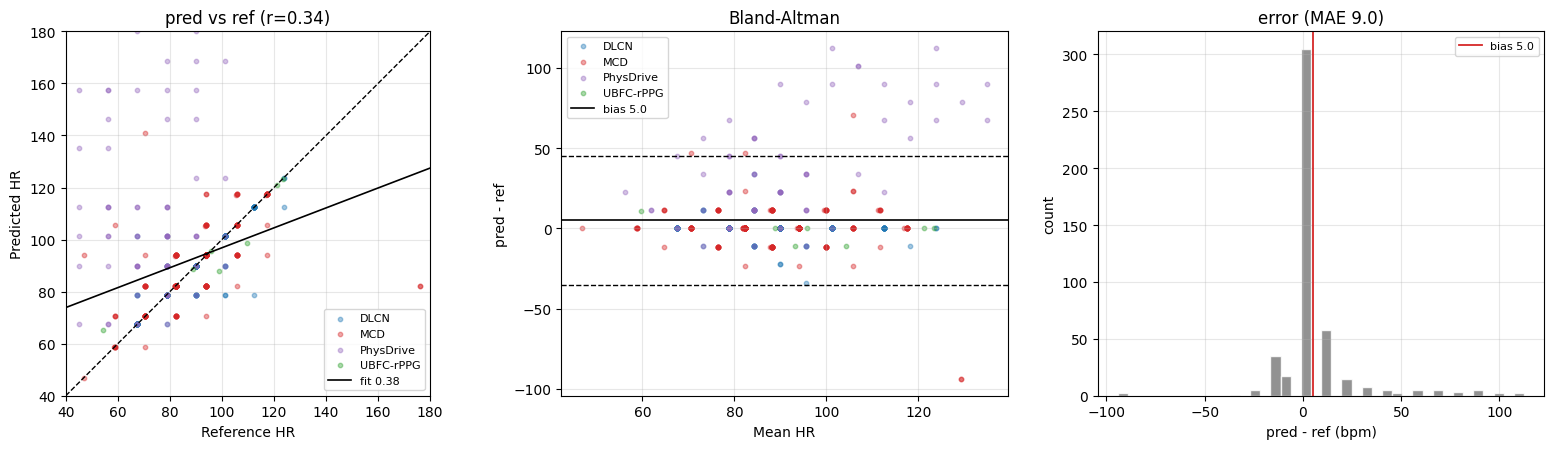

In [8]:
import matplotlib.pyplot as plt

@torch.no_grad()
def collect_predictions(model, loader):
    rows = []
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        with autocast('cuda'):
            pred = rf_forward(model, frames)
        pred = pred.float().cpu().numpy()
        hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if np.isfinite(hp):
                rows.append((ds[i], float(hr_true[i]), hp))
    return pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred'])

def metrics_block(g):
    d = (g['hr_pred'] - g['hr_true']).values
    sd = d.std(ddof=1) if len(d) > 1 else np.nan
    return pd.Series(dict(n=len(g), MAE=np.abs(d).mean(), RMSE=np.sqrt((d ** 2).mean()), bias=d.mean(),
                          LoA_low=d.mean() - 1.96 * sd, LoA_high=d.mean() + 1.96 * sd,
                          Pearson_r=(np.corrcoef(g['hr_true'], g['hr_pred'])[0, 1] if len(g) > 2 else np.nan)))

colors = dict(MCD='tab:red', DLCN='tab:blue')
colors['UBFC-rPPG'] = 'tab:green'; colors['PhysDrive'] = 'tab:purple'
val_loader = make_loader(val_idx, augment=False, clips_per_rec=1)

model = build_rhythmformer().to(device)
model.load_state_dict(torch.load(ckpt, map_location=device)); model.eval()
pred_df = collect_predictions(model, val_loader)
summary = pred_df.groupby('dataset').apply(metrics_block, include_groups=False)
overall = metrics_block(pred_df); overall.name = 'ALL'
zs = [d for d in summary.index if d not in TRAIN_SET]
print('zero-shot datasets:', zs)
print(pd.concat([summary, overall.to_frame().T]).round(2).to_string())

diff = (pred_df.hr_pred - pred_df.hr_true).values
bias = diff.mean(); sd = diff.std(ddof=1)
r = np.corrcoef(pred_df.hr_true, pred_df.hr_pred)[0, 1]
lim = [40, 180]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
for ds, g in pred_df.groupby('dataset'):
    ax[0].scatter(g.hr_true, g.hr_pred, s=10, alpha=0.4, color=colors.get(ds, 'gray'), label=ds)
ax[0].plot(lim, lim, 'k--', lw=1)
sl, ic = np.polyfit(pred_df.hr_true, pred_df.hr_pred, 1)
ax[0].plot(np.array(lim), ic + sl * np.array(lim), 'k-', lw=1.2, label='fit ' + str(round(sl, 2)))
ax[0].set(xlim=lim, ylim=lim, xlabel='Reference HR', ylabel='Predicted HR', title='pred vs ref (r=' + str(round(r, 2)) + ')', aspect='equal')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
for ds, g in pred_df.groupby('dataset'):
    ax[1].scatter((g.hr_true + g.hr_pred) / 2, g.hr_pred - g.hr_true, s=10, alpha=0.4, color=colors.get(ds, 'gray'), label=ds)
ax[1].axhline(bias, color='k', lw=1.2, label='bias ' + str(round(bias, 1)))
ax[1].axhline(bias + 1.96 * sd, color='k', ls='--', lw=1); ax[1].axhline(bias - 1.96 * sd, color='k', ls='--', lw=1)
ax[1].set(xlabel='Mean HR', ylabel='pred - ref', title='Bland-Altman'); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
ax[2].hist(diff, bins=40, color='tab:gray', alpha=0.85, edgecolor='white')
ax[2].axvline(bias, color='tab:red', lw=1.3, label='bias ' + str(round(bias, 1)))
ax[2].set(xlabel='pred - ref (bpm)', ylabel='count', title='error (MAE ' + str(round(np.abs(diff).mean(), 2)) + ')')
ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()
del model; gc.collect(); torch.cuda.empty_cache()

## 9. Discussion and conclusions

RhythmFormer's run on the CRVSE corpus produced the project's best in-distribution result while exposing a sharp generalisation failure, and the two together define its role.

Training ran the full 30-epoch schedule cleanly, the shared MCD+DLCN+UBFC MAE descending steadily from 8.5 to a best of 4.26 at the final epoch. That 4.26 is the lowest shared MAE any CRVSE model has reached - below the SNR-loss PhysNet's 5.22 - and within it MCD falls to 5.77 (unbiased, bias 0.0, r 0.64), the best clean-domain heart-rate result of the phase, with DLCN at 2.14. On the training-distribution datasets RhythmFormer is the strongest model in the project.

The cost lands entirely on the held-out domain. PhysDrive zero-shot finished at 37.4 bpm with a +36.4 bpm bias and a Pearson r of 0.07 - the predictions carry essentially no relationship to the true in-vehicle heart rate, and this is the worst PhysDrive number of any model, worse than the smaller PhysNet (27.8). The per-epoch trace shows the mechanism directly: as the shared MAE improves (8.5 to 4.26), PhysDrive drifts the other way (roughly 20 to 40), so the shared-MAE checkpoint selects precisely the epoch that is worst on PhysDrive. RhythmFormer's cross-dataset design does not, on this corpus, transfer to real driving motion and light; the model specialises to the training domains, and the tighter it fits them the further it drifts from the unseen one.

Two conclusions follow. RhythmFormer is the best available model for an in-distribution population - a still, seated, indoor webcam user close to the training corpus - and a strong candidate there despite its 3.33 M parameters. But it is not the robustness answer: PhysNet v2 (shared 5.22, MCD 6.84, 0.77 M) remains the more balanced deployable backbone, smaller and generalising far better to the unseen domain (27.8 vs 37.4). PhysDrive stays a data problem that no architecture solves - the strongest cross-dataset transformer generalises worst here, and worse the more it trains - so the levers for the in-vehicle / real-world gap remain data (folding PhysDrive-like recordings into training) and targeted domain augmentation (illumination and motion), not a new backbone.